# Instructor Effectiveness Modeling

## Objective
Analyze instructor performance using learner outcomes, engagement metrics, and feedback data. Build a machine learning model to classify instructors into effectiveness tiers.

---

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

pd.set_option("display.max_columns", None)

In [18]:
df = pd.read_csv("../data/dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2000, 12)


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [19]:
print("\nDataset Info")
display(df.info())

print("\nSummary Statistics")
display(df.describe())

print("\nMissing Values")
display(df.isnull().sum())


Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   str    
 1   instructor_id               2000 non-null   str    
 2   course_id                   2000 non-null   str    
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), str(3)
memory usage: 187.6 KB


None


Summary Statistics


,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000



Missing Values


batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [20]:
print("Unique Instructors:", df["instructor_id"].nunique())
print("Unique Courses:", df["course_id"].nunique())
print("Unique Batches:", df["batch_id"].nunique())

Unique Instructors: 120
Unique Courses: 25
Unique Batches: 2000


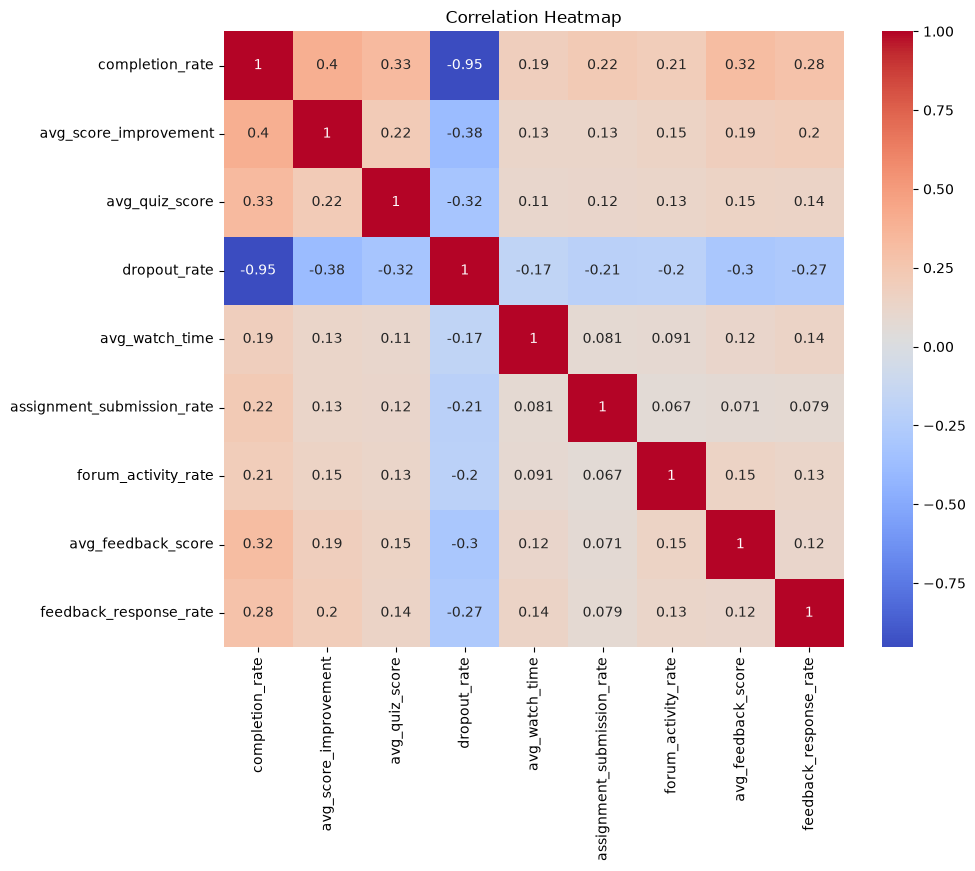

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

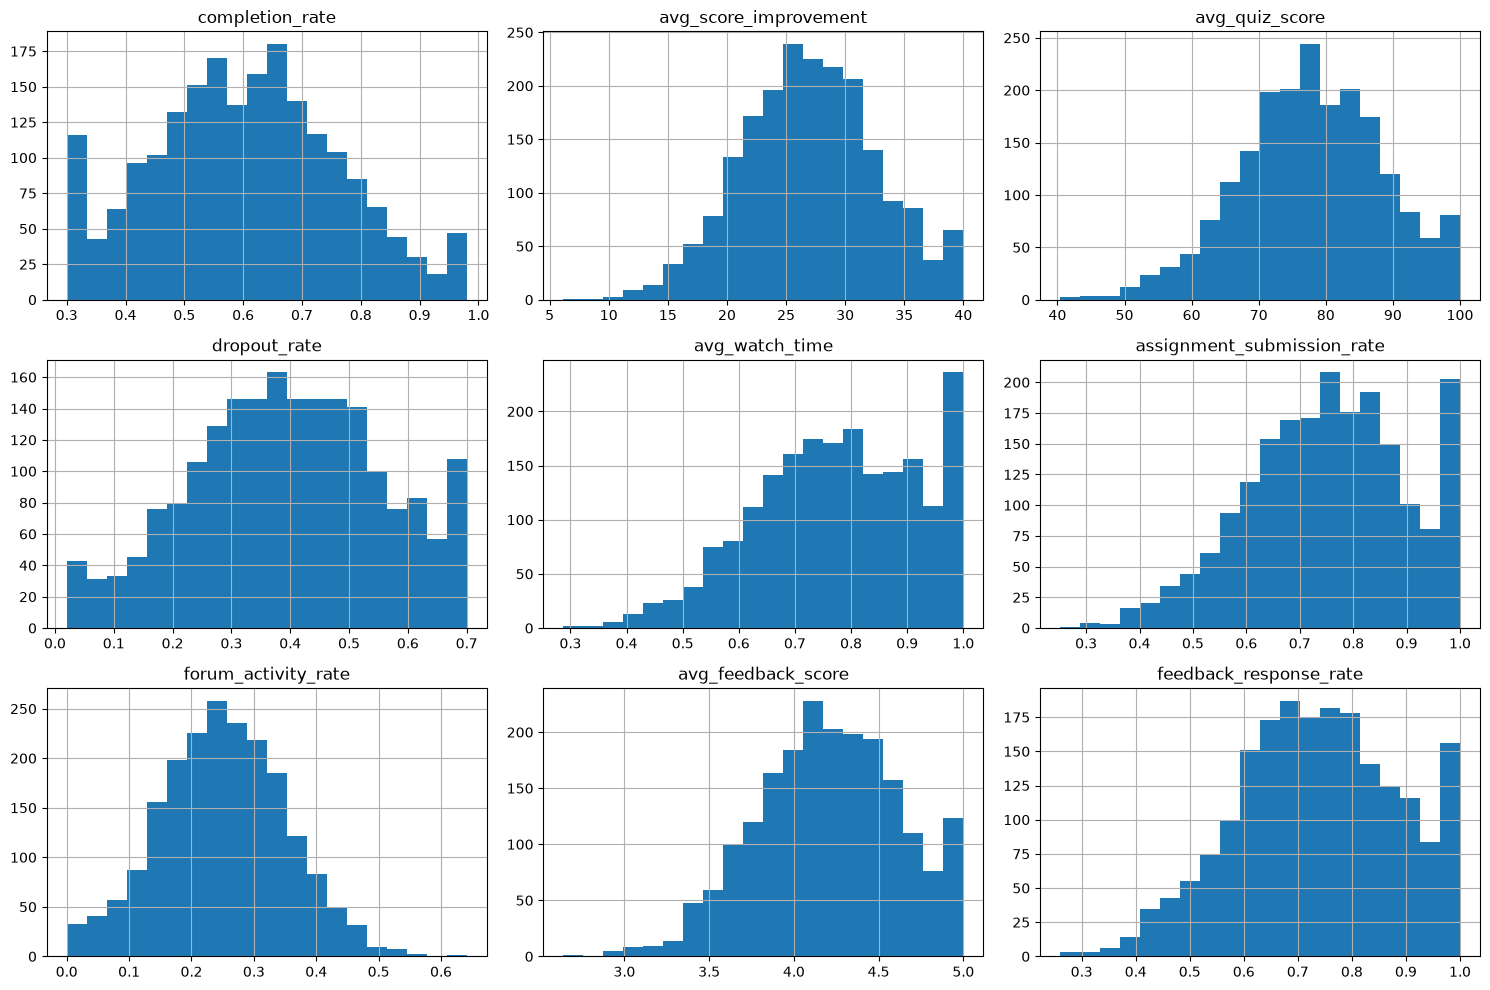

In [22]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

## Defining Instructor Effectiveness

Instructor effectiveness is defined using three dimensions:

1. Learning Outcomes (50%)
2. Engagement (30%)
3. Feedback (20%)

Learning outcomes receive the highest weight because the primary goal of education is learner success.

In [23]:
df["outcome_score"] = (
    0.4 * df["completion_rate"] +
    0.3 * (1 - df["dropout_rate"]) +
    0.3 * (df["avg_score_improvement"] / df["avg_score_improvement"].max())
)

df["engagement_score"] = (
    0.4 * df["avg_watch_time"] +
    0.3 * df["assignment_submission_rate"] +
    0.3 * df["forum_activity_rate"]
)

df["feedback_score"] = (
    0.7 * (df["avg_feedback_score"] / 5) +
    0.3 * df["feedback_response_rate"]
)

df["effectiveness_score"] = (
    0.5 * df["outcome_score"] +
    0.3 * df["engagement_score"] +
    0.2 * df["feedback_score"]
)

df[["effectiveness_score"]].describe()

,effectiveness_score
count,2000.000000
mean,0.658200
std,0.086979
min,0.379568
25%,0.597982
50%,0.659544
75%,0.715836
max,0.908965


## Aggregation Strategy

Batch-level metrics were aggregated to the instructor level using the mean function.

The mean was chosen because it represents an instructor's typical performance across all batches.

Additionally, the number of batches taught was retained as a feature to provide context regarding the reliability of the aggregated metrics. Instructors with more batches have performance estimates based on a larger amount of evidence.

In [24]:
instructor_df = df.groupby("instructor_id").agg({
    "completion_rate": "mean",
    "avg_score_improvement": "mean",
    "avg_quiz_score": "mean",
    "dropout_rate": "mean",
    "avg_watch_time": "mean",
    "assignment_submission_rate": "mean",
    "forum_activity_rate": "mean",
    "avg_feedback_score": "mean",
    "feedback_response_rate": "mean",
    "effectiveness_score": "mean",
    "batch_id": "count",
    "course_id": "nunique"
}).reset_index()

instructor_df.rename(columns={
    "batch_id": "num_batches",
    "course_id": "num_courses_taught"
}, inplace=True)

instructor_df.head()

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,num_batches,num_courses_taught
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,0.626934,25,16
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,0.737131,20,10
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,0.749248,18,14
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,0.586711,17,10
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,0.797604,19,13


## Handling Instructors with Different Numbers of Batches

Instructors taught varying numbers of batches. Aggregating metrics using averages ensured fair comparison across instructors.

The number of batches taught was included as a feature so that the model could distinguish between instructors with limited teaching history and those with extensive teaching history.

In [25]:
instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

instructor_df["effectiveness_tier"].value_counts()

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

In [26]:
X = instructor_df.drop(
    columns=[
        "instructor_id",
        "effectiveness_score",
        "effectiveness_tier"
    ]
)

y = instructor_df["effectiveness_tier"]

X.head()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,num_batches,num_courses_taught
0,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,25,16
1,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,20,10
2,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,18,14
3,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,17,10
4,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,19,13


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(96, 11)
(24, 11)


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

        High       0.88      0.88      0.88         8
         Low       1.00      0.75      0.86         8
      Medium       0.70      0.88      0.78         8

    accuracy                           0.83        24
   macro avg       0.86      0.83      0.84        24
weighted avg       0.86      0.83      0.84        24



In [29]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9166666666666666
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      0.88      0.93         8
      Medium       0.80      1.00      0.89         8

    accuracy                           0.92        24
   macro avg       0.93      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24



## Evaluation Metrics and Trade-offs

Accuracy, Precision, Recall, and F1-Score were used to evaluate model performance.

Precision measures how many predicted instructors in a tier truly belong to that tier, while Recall measures how many actual instructors in a tier were successfully identified.

Since instructor effectiveness classification is a multi-class problem, F1-Score provides a balanced assessment of both Precision and Recall.

In [30]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,dropout_rate,0.265378
0,completion_rate,0.230350
1,avg_score_improvement,0.131128
8,feedback_response_rate,0.117387
7,avg_feedback_score,0.085525
4,avg_watch_time,0.048125
2,avg_quiz_score,0.040751
5,assignment_submission_rate,0.036563
6,forum_activity_rate,0.029304
10,num_courses_taught,0.008126


## Class Imbalance Analysis

The effectiveness tiers were created using quantile-based binning, resulting in 40 instructors in each class (Low, Medium, High).

Therefore, the dataset was balanced and no special techniques such as class weighting or resampling were required.

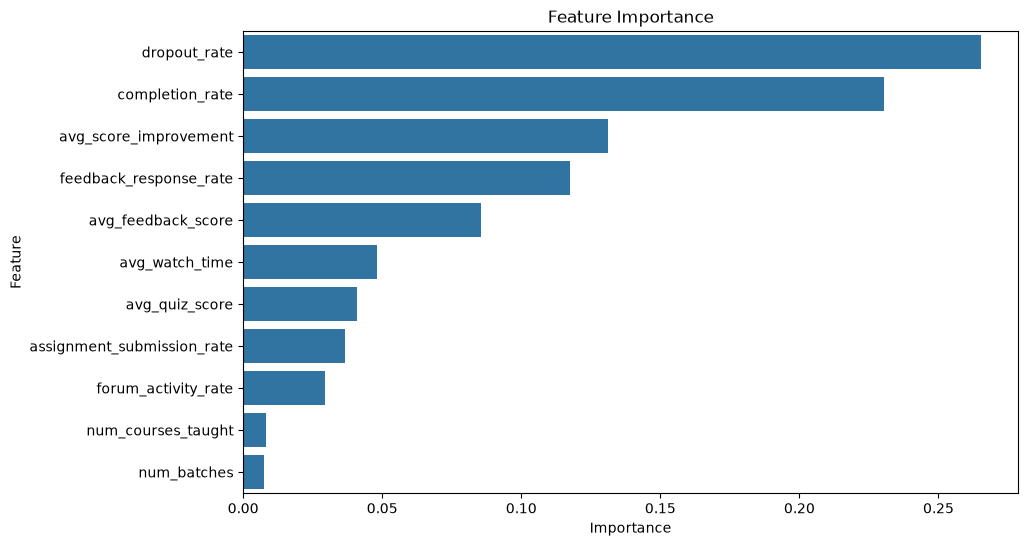

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()


## Key Findings

The most important predictors of instructor effectiveness were:

1. Dropout Rate (26.5%)
2. Completion Rate (23.0%)
3. Average Score Improvement (13.1%)
4. Feedback Response Rate (11.7%)
5. Average Feedback Score (8.6%)

This suggests that learner retention and learning outcomes are stronger indicators of instructor effectiveness than engagement metrics alone.

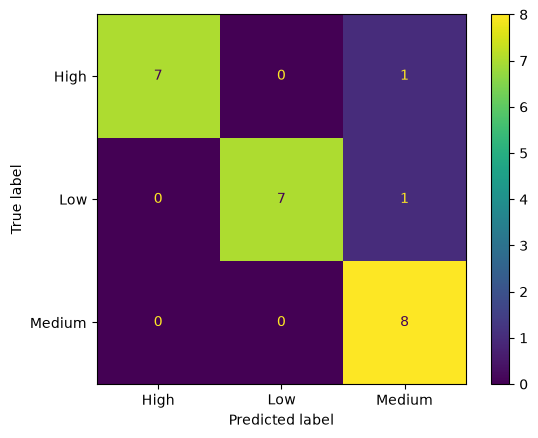

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()

## Confusion Matrix Analysis

The Random Forest model correctly classified 22 out of 24 instructors.

Most classification errors occurred between adjacent tiers (High ↔ Medium and Low ↔ Medium), which is expected because instructor effectiveness exists on a spectrum rather than in strictly separated groups.

Importantly, the model never confused High-performing instructors with Low-performing instructors, indicating strong discrimination ability.

## Q1. Which features most influenced instructor effectiveness, and why?

The most influential features were dropout rate, completion rate, and average score improvement.

Dropout rate had the highest importance because learner retention is a strong indicator of teaching effectiveness. Completion rate reflects how successfully learners progress through the course, while score improvement directly measures learning outcomes.

These features collectively capture both learner engagement and educational impact.

## Q2. Which variables could be misleading or confounded?

Feedback scores may be influenced by factors unrelated to instructor quality, such as course difficulty or learner expectations.

Quiz scores can also be misleading because easier courses may naturally produce higher scores.

Therefore, these variables should be interpreted alongside other performance indicators rather than in isolation.

## Q3. How could this model fail in real-world usage?

The model does not account for course difficulty, learner background, or instructor experience.

An instructor teaching a difficult course may receive lower completion rates despite delivering high-quality instruction.

The model may also struggle with new instructors who have limited historical data.

## Q4. What additional data would improve this analysis?

Additional useful features include:

- Course difficulty ratings
- Instructor experience
- Attendance data
- Live session participation
- Learner demographics
- Written learner feedback
- Historical instructor performance trends

These variables would provide a more complete view of instructor effectiveness.

## Q5. Should this model be used for instructor performance evaluation? Why or why not?

This model should not be used as the sole basis for instructor performance evaluation.

Although the Random Forest model achieved 91.7% accuracy, it does not account for important factors such as course difficulty, learner demographics, instructor experience, and qualitative teaching skills. As a result, relying solely on model predictions could lead to unfair evaluations.

Instead, the model should be used as a decision-support tool alongside human judgment, peer reviews, and qualitative feedback. This approach provides a more balanced and reliable assessment of instructor performance.

## Business Recommendations

1. Identify high-performing instructors and share their teaching practices across the platform.

2. Provide targeted coaching to instructors with consistently low effectiveness scores.

3. Monitor dropout rates as an early warning indicator of learner dissatisfaction.

4. Use effectiveness predictions to prioritize instructor training and support programs.

5. Track instructor performance over time to detect improvement or decline trends.

## Limitations

- Course difficulty was not available.
- Learner demographics were unavailable.
- Instructor experience was unavailable.
- The effectiveness score was based on assumptions and selected weights.
- Historical trends were not considered.

## Future Improvements

- Incorporate course difficulty measures.
- Include instructor experience and qualifications.
- Use time-series analysis to track performance trends.
- Apply SHAP values for advanced model explainability.
- Validate the effectiveness score with business stakeholders.

## Conclusion

This project developed an instructor effectiveness framework using learner outcomes, engagement metrics, and feedback data.

Batch-level information was aggregated to instructor-level features and used to train machine learning models for effectiveness classification.

The Random Forest model achieved 91.7% accuracy and identified dropout rate, completion rate, and score improvement as the strongest predictors of effectiveness.

The model should be used as a decision-support system rather than a standalone evaluation mechanism.